# Legacy Strong Pose Augmentation Experiment

**Use `05_dataset_augmentation_updated.ipynb` for the recommended train/val/test workflow.** This notebook is retained as the earlier, stronger augmentation experiment for controlled comparison only.

Goals:
1. Measure current dataset size and keypoint visibility profile.
2. Define a practical augmentation policy for poultry pose estimation.
3. Generate augmented training frames and YOLO pose labels.

In [1]:
from pathlib import Path
from math import ceil
from collections import Counter
import random
import shutil
import json
import statistics

import cv2
import yaml
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

ROOT = Path('..').resolve()
MERGED = ROOT / 'dataset/pose/pose-dataset-merged'
AUG_OUT = ROOT / 'dataset/pose/pose-dataset-merged-aug'

print('Merged dataset:', MERGED)
print('Augmented output:', AUG_OUT)

c:\dev\poultry-vision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Merged dataset: C:\dev\poultry-vision\dataset\pose\pose-dataset-merged
Augmented output: C:\dev\poultry-vision\dataset\pose\pose-dataset-merged-aug


In [2]:
with open(MERGED / 'data.yaml', 'r', encoding='utf-8') as f:
    merged_cfg = yaml.safe_load(f)

KPT_NAMES = merged_cfg['kpt_names'][0]
N_KPTS = len(KPT_NAMES)

def find_image_for_stem(image_dir: Path, stem: str):
    for ext in ('.jpg', '.jpeg', '.png', '.bmp', '.webp'):
        p = image_dir / f'{stem}{ext}'
        if p.exists():
            return p
    return None

def parse_pose_line(line: str, n_kpts: int):
    vals = [float(x) for x in line.strip().split()]
    if len(vals) < 5 + 3 * n_kpts:
        return None
    cls_id = int(vals[0])
    bbox = vals[1:5]
    kpts = np.array(vals[5:5 + 3 * n_kpts], dtype=np.float32).reshape(n_kpts, 3)
    return cls_id, bbox, kpts

def load_label_instances(label_path: Path, n_kpts: int):
    instances = []
    with open(label_path, 'r', encoding='utf-8') as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            parsed = parse_pose_line(ln, n_kpts=n_kpts)
            if parsed is None:
                continue
            cls_id, bbox, kpts = parsed
            instances.append({'cls': cls_id, 'bbox': bbox, 'kpts': kpts})
    return instances

In [3]:
def analyze_dataset(root: Path, kpt_names: list[str]):
    summary = {}
    kp_labeled = [0] * len(kpt_names)
    kp_visible = [0] * len(kpt_names)
    all_wh = []
    box_w = []
    box_h = []
    total_instances = 0

    for split in ('train', 'val'):
        img_dir = root / 'images' / split
        lbl_dir = root / 'labels' / split
        label_files = sorted(lbl_dir.glob('*.txt'))
        images = [p for p in img_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}]

        split_instances = 0
        unmatched = 0

        for lbl in label_files:
            img_path = find_image_for_stem(img_dir, lbl.stem)
            if img_path is None:
                unmatched += 1
            else:
                img = cv2.imread(str(img_path))
                if img is not None:
                    h, w = img.shape[:2]
                    all_wh.append((w, h))

            instances = load_label_instances(lbl, n_kpts=len(kpt_names))
            for inst in instances:
                split_instances += 1
                total_instances += 1
                box_w.append(inst['bbox'][2])
                box_h.append(inst['bbox'][3])
                for i, (_, _, v) in enumerate(inst['kpts']):
                    if v > 0:
                        kp_labeled[i] += 1
                    if v >= 2:
                        kp_visible[i] += 1

        summary[split] = {
            'images': len(images),
            'labels': len(label_files),
            'instances': split_instances,
            'labels_without_image': unmatched,
        }

    widths = [w for w, _ in all_wh]
    heights = [h for _, h in all_wh]

    report = {
        'split_summary': summary,
        'total_images': summary['train']['images'] + summary['val']['images'],
        'total_instances': total_instances,
        'resolution': {
            'width_min': min(widths) if widths else None,
            'width_max': max(widths) if widths else None,
            'width_median': statistics.median(widths) if widths else None,
            'height_min': min(heights) if heights else None,
            'height_max': max(heights) if heights else None,
            'height_median': statistics.median(heights) if heights else None,
        },
        'bbox_norm': {
            'w_median': statistics.median(box_w) if box_w else None,
            'h_median': statistics.median(box_h) if box_h else None,
        },
        'keypoint_visibility': {
            kpt_names[i]: {
                'labeled_v_gt_0': kp_labeled[i],
                'visible_v_ge_2': kp_visible[i],
                'visible_rate': round(kp_visible[i] / total_instances, 4) if total_instances else 0.0,
            }
            for i in range(len(kpt_names))
        },
    }
    return report

report = analyze_dataset(MERGED, KPT_NAMES)
print(json.dumps(report, indent=2))

{
  "split_summary": {
    "train": {
      "images": 122,
      "labels": 122,
      "instances": 329,
      "labels_without_image": 0
    },
    "val": {
      "images": 31,
      "labels": 31,
      "instances": 131,
      "labels_without_image": 0
    }
  },
  "total_images": 153,
  "total_instances": 460,
  "resolution": {
    "width_min": 640,
    "width_max": 5712,
    "width_median": 4284,
    "height_min": 480,
    "height_max": 5712,
    "height_median": 5712
  },
  "bbox_norm": {
    "w_median": 0.226289,
    "h_median": 0.25727500000000003
  },
  "keypoint_visibility": {
    "tail_base": {
      "labeled_v_gt_0": 431,
      "visible_v_ge_2": 407,
      "visible_rate": 0.8848
    },
    "tail_tip": {
      "labeled_v_gt_0": 426,
      "visible_v_ge_2": 416,
      "visible_rate": 0.9043
    },
    "left_hock": {
      "labeled_v_gt_0": 222,
      "visible_v_ge_2": 154,
      "visible_rate": 0.3348
    },
    "right_hock": {
      "labeled_v_gt_0": 229,
      "visible_v_ge_2":

## Dataset Analysis and Augmentation Plan

Observed from analysis:
- Current merged size is modest for pose training.
- Leg and foot keypoints are much less visible than trunk/head points, so they are the main bottleneck.
- Image dimensions vary a lot, so augmentations must preserve geometry and keypoint consistency.

Updated augmentation policy (train split only, visibility-aware):
1. **Occlusion simulation first** with coarse and grid dropout.
2. **Stronger motion/defocus blur** for moving birds.
3. **Wider scale + affine jitter** to cover camera distance variation.
4. **Safe crop around birds** to create truncation and edge cases while preserving labels.
5. **Targeted synthetic visibility corruption** on leg/foot keypoints to reduce visibility imbalance.
6. Keep **validation split unchanged** for reliable evaluation.

Target: increase train images toward a practical range (~300-400) while improving robustness on hock/foot keypoints.

In [4]:
train_images = report['split_summary']['train']['images']
target_train_images = 360
aug_per_image = max(1, ceil((target_train_images - train_images) / max(train_images, 1)))

print(f'Current train images: {train_images}')
print(f'Target train images: {target_train_images}')
print(f'Augmented copies per train image: {aug_per_image}')

Current train images: 122
Target train images: 360
Augmented copies per train image: 2


In [5]:
LEG_FOOT_KPT_NAMES = {'left_hock', 'right_hock', 'left_foot', 'right_foot'}
LEG_FOOT_KPT_IDX = [i for i, n in enumerate(KPT_NAMES) if n in LEG_FOOT_KPT_NAMES]

augmenter = A.Compose(
    [
        A.RandomSizedBBoxSafeCrop(height=1024, width=1024, p=0.25),
        A.Affine(
            scale=(0.7, 1.3),
            translate_percent=(-0.05, 0.05),
            rotate=(-15, 15),
            shear=(-6, 6),
            p=0.7,
        ),
        A.HorizontalFlip(p=0.0),  # Trainer applies flips with data.yaml flip_idx.
        A.OneOf([
            A.CoarseDropout(
                num_holes_range=(1, 4),
                hole_height_range=(0.05, 0.15),
                hole_width_range=(0.05, 0.15),
                p=1.0,
            ),
            A.GridDropout(ratio=0.2, p=1.0),
        ], p=0.5),
        A.OneOf([
            A.MotionBlur(blur_limit=(3, 7), p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        ], p=0.35),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
            A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20, val_shift_limit=15, p=1.0),
        ], p=0.55),
        A.Perspective(scale=(0.02, 0.06), keep_size=True, p=0.2),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels', 'instance_ids'],
        min_visibility=0.0,
        clip=True,
    ),
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False),
)


def clip01(x):
    return max(0.0, min(1.0, float(x)))


def sanitize_yolo_bbox(bbox, eps=1e-6):
    cx, cy, bw, bh = [float(v) for v in bbox]
    if bw <= 0 or bh <= 0:
        return None

    x1 = cx - bw / 2.0
    y1 = cy - bh / 2.0
    x2 = cx + bw / 2.0
    y2 = cy + bh / 2.0

    x1 = max(0.0, min(1.0, x1))
    y1 = max(0.0, min(1.0, y1))
    x2 = max(0.0, min(1.0, x2))
    y2 = max(0.0, min(1.0, y2))

    if (x2 - x1) <= eps or (y2 - y1) <= eps:
        return None

    cx2 = (x1 + x2) / 2.0
    cy2 = (y1 + y2) / 2.0
    bw2 = (x2 - x1)
    bh2 = (y2 - y1)
    return [cx2, cy2, bw2, bh2]


def apply_leg_visibility_corruption(kpt_arr: np.ndarray, p: float = 0.18):
    # Lower visibility on leg/foot keypoints to emulate frequent occlusion in poultry scenes.
    if not LEG_FOOT_KPT_IDX:
        return kpt_arr
    for idx in LEG_FOOT_KPT_IDX:
        if idx >= len(kpt_arr):
            continue
        if kpt_arr[idx, 2] > 0 and random.random() < p:
            kpt_arr[idx, 2] = 1.0
    return kpt_arr


def apply_augmentation(image_bgr: np.ndarray, instances: list[dict], aug: A.Compose):
    if not instances:
        return image_bgr, []

    h, w = image_bgr.shape[:2]

    valid_instances = []
    for inst in instances:
        safe_bbox = sanitize_yolo_bbox(inst['bbox'])
        if safe_bbox is None:
            continue
        valid_instances.append({
            'cls': int(inst['cls']),
            'bbox': safe_bbox,
            'kpts': inst['kpts'],
        })

    if not valid_instances:
        return image_bgr, []

    bboxes = [inst['bbox'] for inst in valid_instances]
    class_labels = [inst['cls'] for inst in valid_instances]
    instance_ids = list(range(len(valid_instances)))

    keypoints_px = []
    for inst in valid_instances:
        for x, y, _ in inst['kpts']:
            keypoints_px.append((float(x) * w, float(y) * h))

    transformed = aug(
        image=image_bgr,
        bboxes=bboxes,
        class_labels=class_labels,
        instance_ids=instance_ids,
        keypoints=keypoints_px,
    )

    out_img = transformed['image']
    out_h, out_w = out_img.shape[:2]
    out_boxes = transformed['bboxes']
    out_cls = transformed['class_labels']
    out_ids = transformed['instance_ids']
    out_kps_px = transformed['keypoints']

    if len(out_kps_px) != len(valid_instances) * N_KPTS:
        return out_img, []

    all_kps_px = np.array(out_kps_px, dtype=np.float32).reshape(len(valid_instances), N_KPTS, 2)

    out_instances = []
    for i in range(len(out_boxes)):
        src_idx = int(out_ids[i])
        cls_id = int(out_cls[i])
        cx, cy, bw, bh = [float(v) for v in out_boxes[i]]

        safe_box = sanitize_yolo_bbox([cx, cy, bw, bh])
        if safe_box is None:
            continue

        kpt_arr = np.zeros((N_KPTS, 3), dtype=np.float32)
        for j in range(N_KPTS):
            x_px, y_px = all_kps_px[src_idx, j]
            x_n = float(x_px) / max(out_w, 1)
            y_n = float(y_px) / max(out_h, 1)

            old_v = float(valid_instances[src_idx]['kpts'][j, 2])
            if x_n < 0 or x_n > 1 or y_n < 0 or y_n > 1:
                v = 0.0
            else:
                v = old_v

            kpt_arr[j] = [clip01(x_n), clip01(y_n), v]

        kpt_arr = apply_leg_visibility_corruption(kpt_arr, p=0.18)

        out_instances.append({
            'cls': cls_id,
            'bbox': [clip01(v) for v in safe_box],
            'kpts': kpt_arr,
        })

    return out_img, out_instances


def serialize_instances(instances: list[dict]):
    lines = []
    for inst in instances:
        vals = [str(int(inst['cls']))]
        vals += [f'{float(v):.6f}' for v in inst['bbox']]
        vals += [f'{float(v):.6f}' for v in inst['kpts'].reshape(-1)]
        lines.append(' '.join(vals))
    return lines

In [6]:
TARGET_IMG_WIDTH = 640


def resize_keep_aspect(image_bgr: np.ndarray, target_width: int = TARGET_IMG_WIDTH):
    h, w = image_bgr.shape[:2]
    if w <= 0 or h <= 0:
        return image_bgr
    if w == target_width:
        return image_bgr

    scale = float(target_width) / float(w)
    target_height = max(1, int(round(h * scale)))
    return cv2.resize(image_bgr, (target_width, target_height), interpolation=cv2.INTER_AREA)


def prepare_output_dirs(root: Path):
    if root.exists():
        shutil.rmtree(root)
    for split in ('train', 'val'):
        (root / 'images' / split).mkdir(parents=True, exist_ok=True)
        (root / 'labels' / split).mkdir(parents=True, exist_ok=True)


def write_resized_image_and_label(src_img: Path, src_lbl: Path, dst_img: Path, dst_lbl: Path):
    img = cv2.imread(str(src_img))
    if img is None:
        return False

    resized = resize_keep_aspect(img, target_width=TARGET_IMG_WIDTH)
    ok = cv2.imwrite(str(dst_img), resized)
    if not ok:
        return False

    shutil.copy2(src_lbl, dst_lbl)
    return True


def augment_train_split(src_root: Path, dst_root: Path, repeats: int):
    src_img_dir = src_root / 'images' / 'train'
    src_lbl_dir = src_root / 'labels' / 'train'
    dst_img_dir = dst_root / 'images' / 'train'
    dst_lbl_dir = dst_root / 'labels' / 'train'

    label_files = sorted(src_lbl_dir.glob('*.txt'))
    created_aug = 0

    for lbl in label_files:
        img = find_image_for_stem(src_img_dir, lbl.stem)
        if img is None:
            continue

        base_name = lbl.stem
        out_img = dst_img_dir / f'orig_{base_name}{img.suffix.lower()}'
        out_lbl = dst_lbl_dir / f'orig_{base_name}.txt'
        copied_ok = write_resized_image_and_label(img, lbl, out_img, out_lbl)
        if not copied_ok:
            continue

        image_bgr = cv2.imread(str(img))
        if image_bgr is None:
            continue

        instances = load_label_instances(lbl, n_kpts=N_KPTS)
        if not instances:
            continue

        for r in range(repeats):
            aug_img, aug_instances = apply_augmentation(image_bgr, instances, augmenter)
            if not aug_instances:
                continue

            aug_img = resize_keep_aspect(aug_img, target_width=TARGET_IMG_WIDTH)

            aug_name = f'aug{r+1:02d}_{base_name}'
            aug_img_path = dst_img_dir / f'{aug_name}{img.suffix.lower()}'
            aug_lbl_path = dst_lbl_dir / f'{aug_name}.txt'

            ok = cv2.imwrite(str(aug_img_path), aug_img)
            if not ok:
                continue

            lines = serialize_instances(aug_instances)
            with open(aug_lbl_path, 'w', encoding='utf-8') as f:
                f.write('\n'.join(lines) + '\n')
            created_aug += 1

    return created_aug


def copy_val_split(src_root: Path, dst_root: Path):
    src_img_dir = src_root / 'images' / 'val'
    src_lbl_dir = src_root / 'labels' / 'val'
    dst_img_dir = dst_root / 'images' / 'val'
    dst_lbl_dir = dst_root / 'labels' / 'val'

    copied = 0
    for lbl in sorted(src_lbl_dir.glob('*.txt')):
        img = find_image_for_stem(src_img_dir, lbl.stem)
        if img is None:
            continue

        ok = write_resized_image_and_label(img, lbl, dst_img_dir / img.name, dst_lbl_dir / lbl.name)
        if ok:
            copied += 1

    return copied

In [7]:
prepare_output_dirs(AUG_OUT)
aug_created = augment_train_split(MERGED, AUG_OUT, repeats=aug_per_image)
val_copied = copy_val_split(MERGED, AUG_OUT)

aug_cfg = dict(merged_cfg)
aug_cfg['path'] = str(AUG_OUT.resolve())
with open(AUG_OUT / 'data.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(aug_cfg, f, sort_keys=False)

print(f'Created augmented train samples: {aug_created}')
print(f'Copied val pairs: {val_copied}')
print('Wrote:', AUG_OUT / 'data.yaml')

Created augmented train samples: 240
Copied val pairs: 31
Wrote: C:\dev\poultry-vision\dataset\pose\pose-dataset-merged-aug\data.yaml


In [8]:
aug_report = analyze_dataset(AUG_OUT, KPT_NAMES)
print(json.dumps(aug_report['split_summary'], indent=2))
print('Total images:', aug_report['total_images'])
print('Total instances:', aug_report['total_instances'])

{
  "train": {
    "images": 362,
    "labels": 362,
    "instances": 987,
    "labels_without_image": 0
  },
  "val": {
    "images": 31,
    "labels": 31,
    "instances": 131,
    "labels_without_image": 0
  }
}
Total images: 393
Total instances: 1118


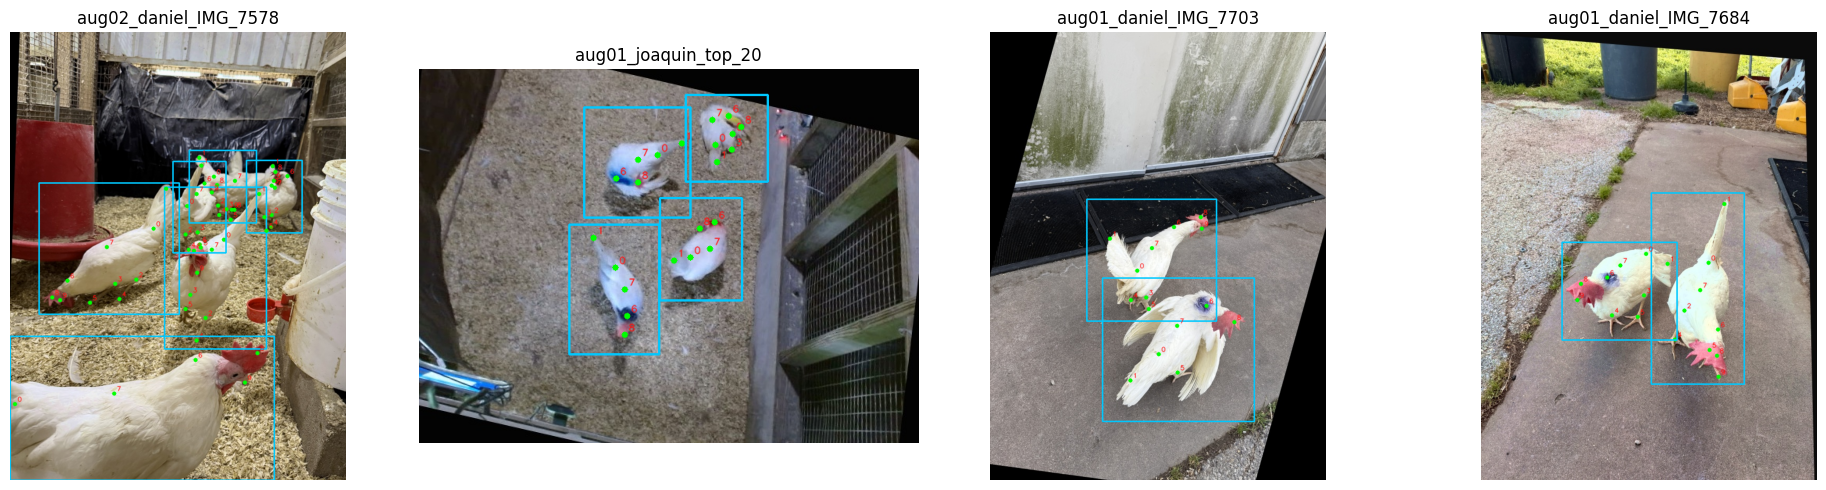

In [15]:
def draw_pose_annotations(image_bgr: np.ndarray, label_path: Path, n_kpts: int):
    h, w = image_bgr.shape[:2]
    out = image_bgr.copy()
    with open(label_path, 'r', encoding='utf-8') as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    for line in lines:
        parsed = parse_pose_line(line, n_kpts=n_kpts)
        if parsed is None:
            continue
        _, (cx, cy, bw, bh), kpts = parsed

        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 200, 0), 2)

        for i, (x, y, v) in enumerate(kpts):
            if v <= 0:
                continue
            px = int(x * w)
            py = int(y * h)
            cv2.circle(out, (px, py), 4, (0, 255, 0), -1)
            cv2.putText(out, str(i), (px + 5, py - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (20, 20, 255), 1, cv2.LINE_AA)

    return out

train_lbl_dir = AUG_OUT / 'labels' / 'train'
train_img_dir = AUG_OUT / 'images' / 'train'
sample_labels = random.sample(sorted(train_lbl_dir.glob('*.txt')), k=min(4, len(list(train_lbl_dir.glob('*.txt')))))

fig, axes = plt.subplots(1, len(sample_labels), figsize=(5 * len(sample_labels), 5))
if len(sample_labels) == 1:
    axes = [axes]

for ax, lbl in zip(axes, sample_labels):
    img_path = find_image_for_stem(train_img_dir, lbl.stem)
    if img_path is None:
        ax.axis('off')
        continue
    img = cv2.imread(str(img_path))
    if img is None:
        ax.axis('off')
        continue

    vis = draw_pose_annotations(img, lbl, n_kpts=N_KPTS)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(lbl.stem)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Next Training Step

Train with the new dataset config (images are normalized to width 640, aspect ratio preserved):

`yolo pose train data=dataset/pose/pose-dataset-merged-aug/data.yaml model=yolov8n-pose.pt epochs=100 imgsz=640`